In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

## 1.Data Collection 

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400
2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600
2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000
...,...,...,...,...,...
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400
2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600
2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800


## 2.Data Exploration & Visualization

In [5]:
type(df)

pandas.DataFrame

In [6]:
df.shape

(2512, 5)

In [7]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2512.000000,2512.000000,2512.000000,2512.000000,2.512000e+03
mean,126.640287,127.915279,125.254499,126.526029,9.572879e+07
std,77.885958,78.665928,77.061525,77.821714,5.466117e+07
min,21.747375,21.776971,21.483303,21.535661,1.791060e+07
25%,45.602932,46.026899,45.244693,45.630975,5.656430e+07
50%,131.173103,132.603861,129.812064,131.521122,8.388080e+07
75%,182.581417,184.371773,180.725090,182.300912,1.156325e+08
max,315.200012,317.399994,309.649994,314.179993,4.479400e+08


In [9]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [10]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400
2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600
2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000


In [11]:
df = df.reset_index()

In [12]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2,2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400
3,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000
...,...,...,...,...,...,...
2507,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2508,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2509,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


Text(0, 0.5, 'Close price')

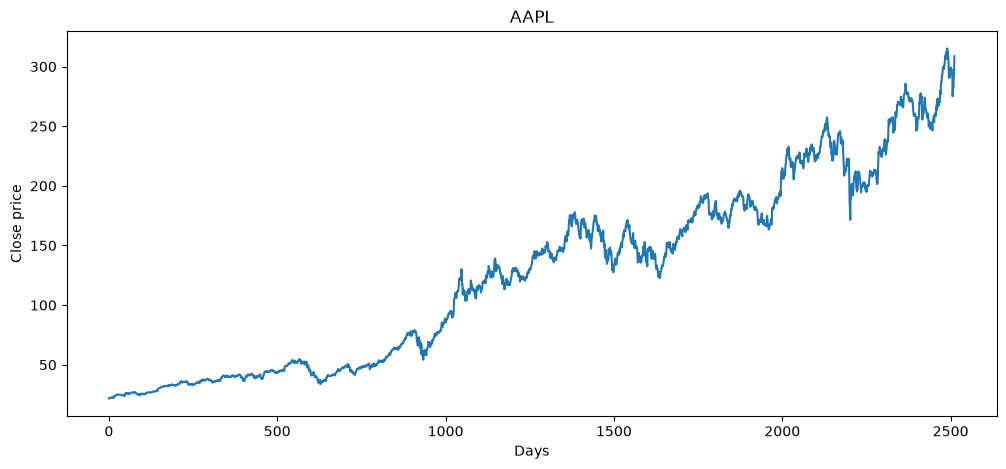

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

## 3.Feature Engineering

In [14]:
temp_df = [10,20,30,40,50,60,70,80,90,100]
print(sum(temp_df[2:7])/5)

50.0


In [15]:
df1 = pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [16]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 days of Moving Average

In [17]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN
2,2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400,NaN
3,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN


In [18]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN
2,2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400,NaN
3,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN
...,...,...,...,...,...,...,...
98,2016-11-22,25.720486,25.863121,25.628462,25.754993,103862000,NaN
99,2016-11-23,25.589350,25.653766,25.382297,25.619257,109705600,24.901193
100,2016-11-25,25.718187,25.736592,25.524938,25.566348,45903600,24.940901


Text(0, 0.5, 'Price')

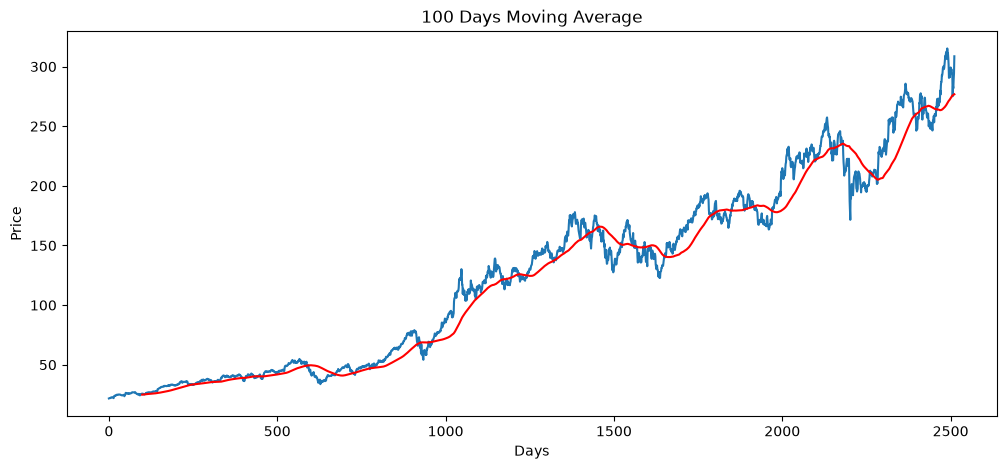

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df["MA_100"], 'r')
plt.title("100 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Price')

### 100 days of Moving Average

In [20]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400,NaN,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
2,2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400,NaN,NaN
3,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600,NaN,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN,NaN


In [21]:
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400,NaN,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
2,2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400,NaN,NaN
3,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600,NaN,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2017-04-19,32.504875,32.809870,32.451733,32.782145,69313600,29.594022,NaN
199,2017-04-20,32.911522,33.022427,32.615771,32.629634,93278400,29.667244,27.284219
200,2017-04-21,32.872272,32.967003,32.775230,32.911552,69283600,29.738785,27.339843


Text(0, 0.5, 'Price')

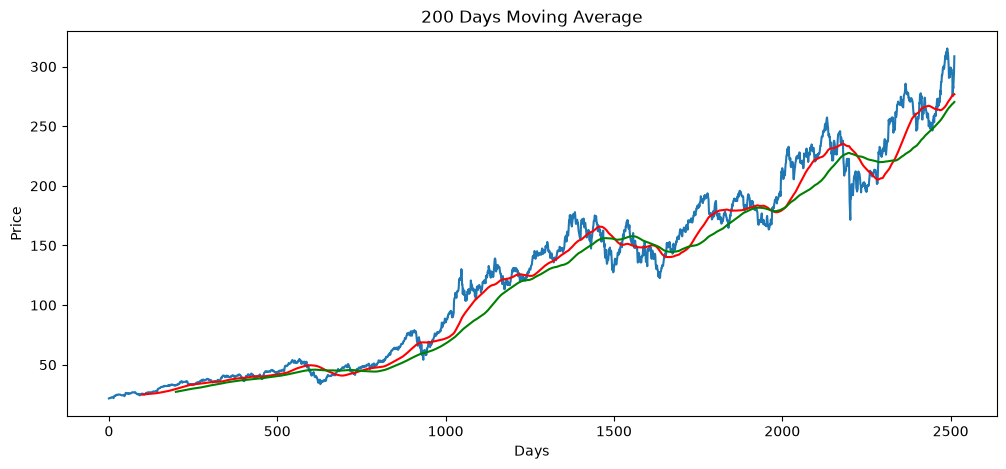

In [22]:
 plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df["MA_100"], 'r')
plt.plot(df["MA_200"], 'g')
plt.title("200 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Price')

In [23]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-06,21.747375,21.776971,21.483303,21.535661,123796400,NaN,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
2,2016-07-08,22.009165,22.056971,21.865746,21.965911,115648400,NaN,NaN
3,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600,NaN,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN,NaN
...,...,...,...,...,...,...,...,...
2507,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500,275.981114,269.075539
2508,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000,276.108711,269.353488
2509,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200,276.242539,269.653383


### Calculating % changed in each trading session

In [24]:
df["Percentage changed"] = df.Close.pct_change()


In [25]:
df[['Close', 'Percentage changed']]

Price,Close,Percentage changed
Ticker,AAPL,
0,21.747375,NaN
1,21.840704,0.004291
2,22.009165,0.007713
3,22.077461,0.003103
4,22.177628,0.004537
...,...,...
2507,283.779999,0.031365
2508,281.739990,-0.007189
2509,289.359985,0.027046


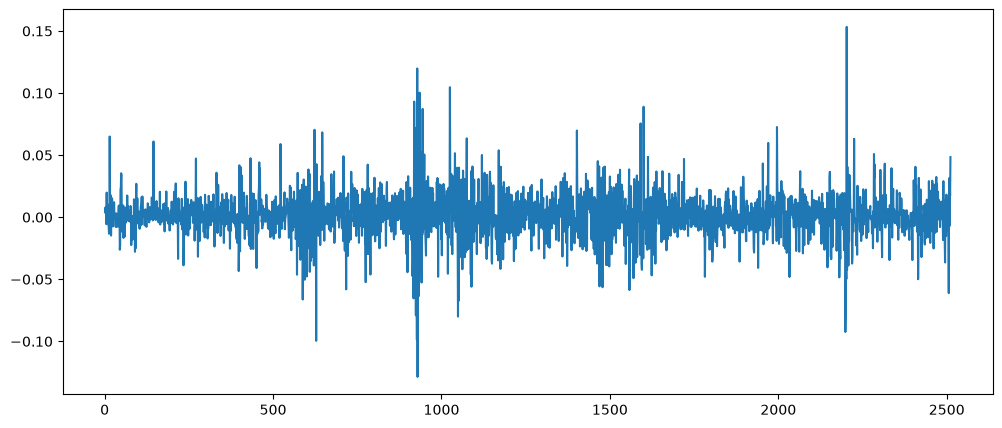

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage changed'])

## 4.Data Preprocessing

In [27]:
df.shape

(2512, 9)

In [28]:
# Splitting data into Training and Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

Ticker        AAPL
0        21.747375
1        21.840704
2        22.009165
3        22.077461
4        22.177628
...            ...
1753    184.099091
1754    182.708572
1755    185.460007
1756    186.633530
1757    186.968826

[1758 rows x 1 columns]
Ticker        AAPL
1758    191.288300
1759    189.799149
1760    188.684784
1761    189.158142
1762    188.043762
...            ...
2507    283.779999
2508    281.739990
2509    289.359985
2510    294.380005
2511    308.630005

[754 rows x 1 columns]


In [29]:
# Scaling down the data between 0 and 1

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [31]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00000000e+00],
       [5.64869002e-04],
       [1.58447539e-03],
       ...,
       [9.90867895e-01],
       [9.97970623e-01],
       [1.00000000e+00]], shape=(1758, 1))

In [32]:
type(data_training_array)

numpy.ndarray

In [33]:
data_training_array.shape

(1758, 1)

## 5.Sequence Creation

In [34]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [35]:
x_train

array([[[0.00000000e+00],
        [5.64869002e-04],
        [1.58447539e-03],
        ...,
        [2.39497022e-02],
        [2.40471814e-02],
        [2.32534834e-02]],

       [[5.64869002e-04],
        [1.58447539e-03],
        [1.99783837e-03],
        ...,
        [2.40471814e-02],
        [2.32534834e-02],
        [2.40332706e-02]],

       [[1.58447539e-03],
        [1.99783837e-03],
        [2.60409331e-03],
        ...,
        [2.32534834e-02],
        [2.40332706e-02],
        [2.37269339e-02]],

       ...,

       [[7.33896979e-01],
        [7.65975711e-01],
        [7.87876804e-01],
        ...,
        [9.84540753e-01],
        [9.82630974e-01],
        [9.74214886e-01]],

       [[7.65975711e-01],
        [7.87876804e-01],
        [7.71391324e-01],
        ...,
        [9.82630974e-01],
        [9.74214886e-01],
        [9.90867895e-01]],

       [[7.87876804e-01],
        [7.71391324e-01],
        [7.88769678e-01],
        ...,
        [9.74214886e-01],
        [9.9086

In [36]:
y_train

array([0.02403327, 0.02372693, 0.02357379, ..., 0.9908679 , 0.99797062,
       1.        ], shape=(1658,))

In [37]:
y_train.ndim

1

In [38]:
x_train.shape

(1658, 100, 1)

In [39]:
y_train.shape

(1658,)

## 6.Model Building

In [40]:
!pip install tensorflow

In [41]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [42]:
# ML Model
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input


In [43]:
model = Sequential()

model.add(Input(shape= (100, 1)))
model.add(LSTM(units=128, activation = 'tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(1))

## 7.Model Training

In [44]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0135
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 7.1687e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 6.0463e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 6.7414e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 6.4185e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 5.9984e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 6.4346e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 5.7920e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.7726e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 4.7956e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 4.4801e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 4.4599e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.1982e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 4.2520e-04
Epoch 15/50
52/52 ━

In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 348,101 (1.33 MB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 232,068 (906.52 KB)

In [46]:
import tensorflow as tf
print(tf.__version__)


2.21.0


In [47]:
import keras
print(keras.__version__)

3.15.0


In [48]:
!pip install h5py

In [49]:
#model.save('stock_prediction_model.keras')

## 8.Preparing Test Data

In [50]:
data_training.tail(100)

Ticker,AAPL
1658,149.197769
1659,152.069046
1660,149.384598
1661,148.352142
1662,148.716537
...,...
1753,184.099091
1754,182.708572
1755,185.460007
1756,186.633530


In [51]:
data_testing

Ticker,AAPL
1758,191.288300
1759,189.799149
1760,188.684784
1761,189.158142
1762,188.043762
...,...
2507,283.779999
2508,281.739990
2509,289.359985
2510,294.380005


In [52]:
past_100_days = data_training.tail(100)

In [53]:
past_100_days

Ticker,AAPL
1658,149.197769
1659,152.069046
1660,149.384598
1661,148.352142
1662,148.716537
...,...
1753,184.099091
1754,182.708572
1755,185.460007
1756,186.633530


In [54]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,149.197769
1,152.069046
2,149.384598
3,148.352142
4,148.716537
...,...
849,283.779999
850,281.739990
851,289.359985
852,294.380005


In [55]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.03541432],
       [0.05209839],
       [0.03649992],
       [0.03050065],
       [0.03261804],
       [0.0488696 ],
       [0.04515015],
       [0.05733887],
       [0.04806861],
       [0.04143043],
       [0.01814037],
       [0.02060088],
       [0.02340488],
       [0.00801176],
       [0.0149357 ],
       [0.01201724],
       [0.        ],
       [0.00343351],
       [0.03273241],
       [0.04875531],
       [0.03599436],
       [0.04326161],
       [0.03021462],
       [0.01825466],
       [0.02952783],
       [0.04165945],
       [0.0439484 ],
       [0.06031452],
       [0.05545041],
       [0.06918428],
       [0.07994249],
       [0.07164506],
       [0.07793957],
       [0.08549312],
       [0.07422003],
       [0.07061487],
       [0.08846895],
       [0.09756764],
       [0.11210249],
       [0.11937001],
       [0.1162798 ],
       [0.10557878],
       [0.11072935],
       [0.0956791 ],
       [0.0886406 ],
       [0.08463476],
       [0.1158794 ],
       [0.113

In [56]:
input_data.shape

(854, 1)

In [57]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i,0])

In [58]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [59]:
x_test

array([[[0.03541432],
        [0.05209839],
        [0.03649992],
        ...,
        [0.24612253],
        [0.25294149],
        [0.25488979]],

       [[0.05209839],
        [0.03649992],
        [0.03050065],
        ...,
        [0.25294149],
        [0.25488979],
        [0.27998886]],

       [[0.03649992],
        [0.03050065],
        [0.03261804],
        ...,
        [0.25488979],
        [0.27998886],
        [0.27133589]],

       ...,

       [[0.77208904],
        [0.76872531],
        [0.78154292],
        ...,
        [0.76728222],
        [0.8174284 ],
        [0.80557457]],

       [[0.76872531],
        [0.78154292],
        [0.76273376],
        ...,
        [0.8174284 ],
        [0.80557457],
        [0.84985191]],

       [[0.78154292],
        [0.76273376],
        [0.75727667],
        ...,
        [0.80557457],
        [0.84985191],
        [0.87902163]]], shape=(754, 100, 1))

In [60]:
y_test

array([0.27998886, 0.27133589, 0.26486067, 0.2676112 , 0.2611359 ,
       0.24927426, 0.24623717, 0.2559214 , 0.26033385, 0.26119318,
       0.28010342, 0.27861351, 0.28646408, 0.2751753 , 0.26835616,
       0.2729978 , 0.27798329, 0.28302587, 0.27569097, 0.29064724,
       0.29419992, 0.28938662, 0.27202392, 0.2639438 , 0.21133932,
       0.19334613, 0.19878991, 0.18956399, 0.18830337, 0.18864756,
       0.19823009, 0.18669678, 0.18164728, 0.16690025, 0.16971187,
       0.17745835, 0.1854342 , 0.20775543, 0.18055698, 0.19335278,
       0.20241902, 0.22496971, 0.24522516, 0.24648738, 0.25561099,
       0.25698811, 0.2180267 , 0.18732798, 0.19088544, 0.19765661,
       0.18009796, 0.16810528, 0.17688461, 0.17269568, 0.18968058,
       0.19599239, 0.17545011, 0.16649852, 0.17143328, 0.17883548,
       0.15519484, 0.14641525, 0.14790729, 0.15089109, 0.16546567,
       0.15771928, 0.16494938, 0.17212194, 0.18692615, 0.19553338,
       0.19209038, 0.20018114, 0.20540291, 0.19472991, 0.19398

## 9.Making Predictions

In [61]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [62]:
y_predicted

array([[0.25068557],
       [0.26183173],
       [0.26935413],
       [0.27158862],
       [0.27206624],
       [0.2698224 ],
       [0.2638413 ],
       [0.25745025],
       [0.25551468],
       [0.25697565],
       [0.25957483],
       [0.26740745],
       [0.27448013],
       [0.28163442],
       [0.2833457 ],
       [0.28060457],
       [0.27840886],
       [0.2784335 ],
       [0.28071585],
       [0.28099728],
       [0.2850006 ],
       [0.2901845 ],
       [0.29286975],
       [0.28872272],
       [0.2810782 ],
       [0.2592468 ],
       [0.23429428],
       [0.21678329],
       [0.20406407],
       [0.19618347],
       [0.19226635],
       [0.19337143],
       [0.19307415],
       [0.19106078],
       [0.18505582],
       [0.17979017],
       [0.1779924 ],
       [0.17991385],
       [0.18851823],
       [0.19032899],
       [0.19253853],
       [0.19657695],
       [0.20621163],
       [0.22093952],
       [0.23406619],
       [0.24562015],
       [0.25370854],
       [0.247

In [63]:
y_test

array([0.27998886, 0.27133589, 0.26486067, 0.2676112 , 0.2611359 ,
       0.24927426, 0.24623717, 0.2559214 , 0.26033385, 0.26119318,
       0.28010342, 0.27861351, 0.28646408, 0.2751753 , 0.26835616,
       0.2729978 , 0.27798329, 0.28302587, 0.27569097, 0.29064724,
       0.29419992, 0.28938662, 0.27202392, 0.2639438 , 0.21133932,
       0.19334613, 0.19878991, 0.18956399, 0.18830337, 0.18864756,
       0.19823009, 0.18669678, 0.18164728, 0.16690025, 0.16971187,
       0.17745835, 0.1854342 , 0.20775543, 0.18055698, 0.19335278,
       0.20241902, 0.22496971, 0.24522516, 0.24648738, 0.25561099,
       0.25698811, 0.2180267 , 0.18732798, 0.19088544, 0.19765661,
       0.18009796, 0.16810528, 0.17688461, 0.17269568, 0.18968058,
       0.19599239, 0.17545011, 0.16649852, 0.17143328, 0.17883548,
       0.15519484, 0.14641525, 0.14790729, 0.15089109, 0.16546567,
       0.15771928, 0.16494938, 0.17212194, 0.18692615, 0.19553338,
       0.19209038, 0.20018114, 0.20540291, 0.19472991, 0.19398

In [64]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [65]:
y_predicted

array([186.24529, 188.16351, 189.4581 , 189.84265, 189.92484, 189.53868,
       188.50937, 187.40948, 187.07637, 187.32779, 187.77512, 189.12308,
       190.34027, 191.57149, 191.866  , 191.39426, 191.01639, 191.02063,
       191.41342, 191.46184, 192.15082, 193.04292, 193.50507, 192.79137,
       191.47577, 187.71866, 183.4244 , 180.41081, 178.22188, 176.86566,
       176.19151, 176.3817 , 176.33055, 175.98404, 174.9506 , 174.04442,
       173.73503, 174.06569, 175.54648, 175.85812, 176.23837, 176.93336,
       178.59146, 181.12608, 183.38515, 185.37354, 186.76553, 185.6236 ,
       182.46133, 179.66412, 178.04846, 176.4952 , 174.8724 , 174.04713,
       173.54358, 174.04608, 175.08293, 175.14706, 174.43822, 173.8266 ,
       173.71272, 172.76805, 171.38736, 170.2506 , 169.60576, 169.92346,
       170.20197, 170.71823, 171.50467, 172.84448, 174.44101, 175.57492,
       176.60364, 177.5507 , 177.72177, 177.52655, 176.83252, 175.80467,
       174.83101, 173.48137, 172.38423, 171.76842, 

In [66]:
y_test

array([191.28829956, 189.79914856, 188.68478394, 189.15814209,
       188.04376221, 186.00241089, 185.47973633, 187.1463623 ,
       187.9057312 , 188.05361938, 191.30801392, 191.05160522,
       192.40266418, 190.4598999 , 189.28634644, 190.0851593 ,
       190.94314575, 191.81095886, 190.54864502, 193.12257385,
       193.73397827, 192.90562439, 189.91755676, 188.5269928 ,
       179.47392273, 176.37734985, 177.31420898, 175.72645569,
       175.50950623, 175.56874084, 177.21786499, 175.23301697,
       174.36401367, 171.82609558, 172.30996704, 173.64311218,
       175.01573181, 178.85714722, 174.17637634, 176.37849426,
       177.93876648, 181.81967163, 185.30557251, 185.52279663,
       187.09294128, 187.3299408 , 180.62480164, 175.34164429,
       175.95387268, 177.11917114, 174.09738159, 172.03347778,
       173.54437256, 172.82347107, 175.746521  , 176.83276367,
       173.29750061, 171.75695801, 172.60621643, 173.88011169,
       169.81163025, 168.3006897 , 168.5574646 , 169.07

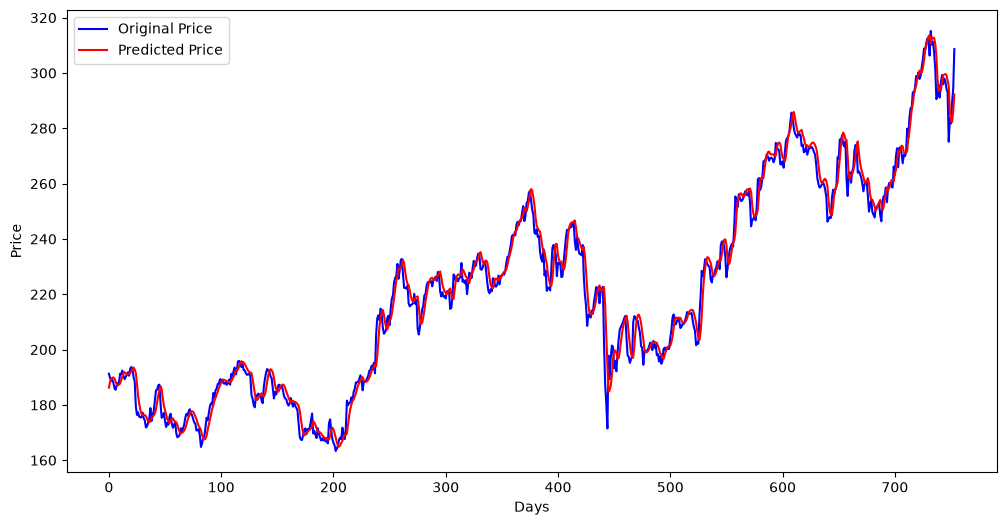

In [67]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_predicted, 'r', label = "Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

(160.0, 320.0)

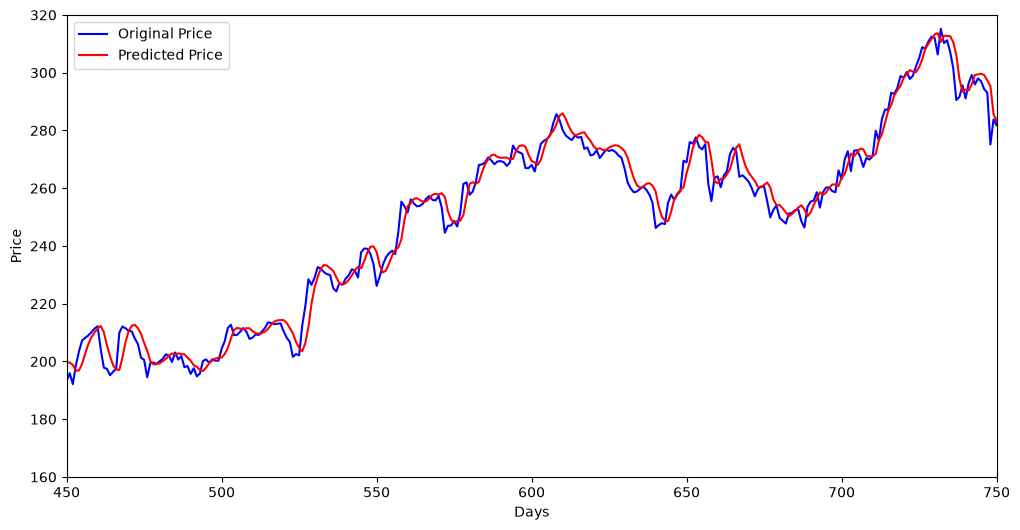

In [68]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_predicted, 'r', label = "Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.xlim(450, 750)
plt.ylim(160, 320)

## 10.Model Evaluation

In [69]:
# Mean Squared Error(MSE)

from sklearn.metrics import mean_squared_error, r2_score

In [70]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE):{mse}")

Mean Squared Error (MSE):22.458200164612354


In [71]:
# Root Mean Squared Erroe (RMSE)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE):{rmse}")

Root Mean Squared Error (RMSE):4.7390083524522675


In [73]:
# R-Squared

r2 = r2_score(y_test, y_predicted)
print(f"R_Score: {r2}")

R_Score: 0.9834362395556311
